# Shared Setup
This notebook uses shared imports, plotting parameters, and variable definitions to reduce code duplication across cells.

In [1]:
# Shared imports and plotting parameters
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 20,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20
})


In [100]:
# Shared variables and helper functions
MODEL_LABELS = ['Llama-3.1-8B', 'Command-R', 'GPT-4o-Mini', 'GPT-4o']
MODELS = ['llama8b', 'commandr', 'gpt-4o-mini', 'gpt-4o']

Y_LABELS = {
    'KB CS': 'KB CS →',
    'Consistency CS all': 'Cst CS →',
    'Delta CS': 'Δ CS ←',
    # 'Cst CS': 'Cst CS →'
}

BAR_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

CI_MAP = {
    'KB CS': 'KB CS CI',
    'Consistency CS all': 'Consistency CS all CI',
    'Delta CS': 'Delta CS CI'
}

METRICS = ['KB CS', 'Consistency CS all', 'Delta CS']
HATCHING_PATTERNS = ['xxx', '\\\\\\', '///']
IR_MODE_COLORS = {'qlang': BAR_COLORS[1], 'rel_langs': BAR_COLORS[4]}  # orange and purple


In [109]:

def draw_no_ir_baseline(ax, no_ir_data, metric, languages, categories, bar_width, plot_idx):
    """Helper function to draw no_ir baseline dotted lines"""
    if len(no_ir_data) > 0 and metric in no_ir_data.columns:
        baseline_value = no_ir_data[metric].mean()
        if np.isfinite(baseline_value):
            # Draw dotted line across each set of bars
            for lang_idx in range(len(languages)):
                start_pos = lang_idx - bar_width * len(categories)/2 - bar_width * 0.3
                end_pos = lang_idx + bar_width * len(categories)/2 + bar_width * 0.3
                ax.plot([start_pos, end_pos], [baseline_value, baseline_value],
                        linestyle=':', color=BAR_COLORS[0], linewidth=2, alpha=0.7)
                # Add value label at the start of the dotted line
                ax.text(start_pos, baseline_value + 1.0, f'{baseline_value:.1f}',
                        ha='center', va='bottom', color=BAR_COLORS[0], fontsize=14)
            # Add invisible bar for legend (only on first subplot)
            if plot_idx == 0:
                ax.bar(0, 0, label='no_ir', color=BAR_COLORS[0], alpha=0.7)

def plot_modes(df, models, model_labels, ir_modes, bar_colors, y_labels, ci_map=None, figsize=(20,10), bar_width=0.12):
    """
    Plots bar charts for KB CS, Consistency CS all, and Delta CS for given modes.
    Shows error bars if the CI field exists in the dataframe for the metric.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    fig = plt.figure(figsize=figsize)
    metrics = METRICS
    for plot_idx, metric in enumerate(metrics):
        ax = plt.subplot(3, 1, plot_idx + 1)
        index = np.arange(len(models))
        for i, ir_mode in enumerate(ir_modes):
            mode_data = df[df['IR Mode'] == ir_mode]
            mode_data = mode_data[mode_data['Model'].isin(models)]
            if len(mode_data) == 0:
                continue
            model_positions = {model: idx for idx, model in enumerate(models)}
            x_pos = np.array([model_positions[model] for model in mode_data['Model']])
            x_pos = x_pos + (i - len(ir_modes)/2 + 0.5) * bar_width
            values = mode_data[metric].values
            yerr = None
            show_ci = False
            if ci_map is not None and metric in ci_map and ci_map[metric] in mode_data.columns:
                ci_col = ci_map[metric]
                yerr = mode_data[ci_col].values
                if yerr is not None and np.all(np.isfinite(yerr)):
                    show_ci = True
            if ir_mode == 'no_ir':
                for idx, (pos, val) in enumerate(zip(x_pos, values)):
                    start = pos
                    width = len(ir_modes)
                    end = pos + width * bar_width
                    ax.plot([start, end], [val, val],
                            linestyle=':', color=bar_colors[i], linewidth=2)
                    # Draw error bar at the left side of the dotted line if show_ci
                    if show_ci and yerr is not None:
                        ax.errorbar(start, val, yerr=yerr[idx], color=bar_colors[i], capsize=6, elinewidth=2)
                ax.bar(0, 0, label=ir_mode, color=bar_colors[i], alpha=0.7)
            else:
                bar_kwargs = dict()
                if show_ci:
                    bar_kwargs['yerr'] = yerr
                    bar_kwargs['capsize'] = 6
                    bar_kwargs['ecolor'] = bar_colors[i]
                    bar_kwargs['error_kw'] = {'elinewidth':2}
                ax.bar(x_pos, values, bar_width, label=ir_mode, color=bar_colors[i], alpha=0.7, **bar_kwargs)
            for j, (pos, val) in enumerate(zip(x_pos, values)):
                label = f'{val:.1f}'
                yerr_val = yerr[j] if show_ci else 0
                offset = 1.5
                if metric == 'Delta CS' and val < 0:
                    ax.text(pos, val - yerr_val - offset, label, ha='center', va='top', color=bar_colors[i], fontsize=18, rotation=0)
                else:
                    ax.text(pos, val + yerr_val + offset, label, ha='center', va='bottom', color=bar_colors[i], fontsize=18, rotation=0)
        ax.set_facecolor('#F5F5F5')
        ax.grid(True, axis='y', linestyle='--', alpha=0.3)
        ax.set_ylabel(y_labels[metric])
        ax.set_xticks(index)
        ax.set_xticklabels(model_labels, rotation=0, ha='center')
        if metric == 'Delta CS':
            # ax.set_ylim(-10, 40)
            ax.set_ylim(0, 40)
        else:
            ax.set_ylim(50, 100)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=len(ir_modes), frameon=True)
    plt.subplots_adjust(hspace=0.2, top=0.9)

    fig.text(0.05, 0.08, 'all 720 queries', fontsize=12, style='italic', alpha=0.7)
    # fig.text(0.1, 0.08, 'all 720 queries', fontsize=12, style='italic', alpha=0.7)
#

    plt.show()

def plot_relevance_filter(data, languages, categories, bar_width=0.15, figsize=(10,10), ci_map=None):
    """
    Plots the relevance filter bar chart for KB CS, Consistency CS all, and Delta CS by language and doc filter category.
    Includes error bars, consistent colors with plot_modes, and dotted lines for no_ir baselines.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Create figure
    fig = plt.figure(figsize=figsize)

    # Define variables
    index = np.arange(len(languages))

    # Use consistent colors with plot_modes: orange for qlang, purple for rel_langs
    bar_colors = BAR_COLORS
    colors = IR_MODE_COLORS
    ir_modes = ['qlang', 'rel_langs']

    # Define hatching patterns
    hatches = HATCHING_PATTERNS

    # Check if we have no_ir data for dotted lines
    no_ir_data = data[data['IR Mode'] == 'no_ir']
    has_no_ir = len(no_ir_data) > 0    # Get y_labels for consistency
    y_labels = Y_LABELS
    metrics = METRICS

    for plot_idx, metric in enumerate(metrics):
        ax = plt.subplot(3, 1, plot_idx + 1)

        # Draw no_ir baseline as dotted lines if available
        if has_no_ir and metric in no_ir_data.columns:
            baseline_value = no_ir_data[metric].mean()
            if np.isfinite(baseline_value):
                # Draw dotted line across each set of bars (consistent with plot_modes)
                for lang_idx in range(len(languages)):
                    start_pos = lang_idx - bar_width * len(categories)/2 - bar_width * 0.3
                    end_pos = lang_idx + bar_width * len(categories)/2 + bar_width * 0.3
                    ax.plot([start_pos, end_pos], [baseline_value, baseline_value],
                            linestyle=':', color=bar_colors[0], linewidth=2, alpha=0.7)
                    # Add value label at the start of the dotted line
                    ax.text(start_pos, baseline_value + 1.0, f'{baseline_value:.1f}',
                            ha='center', va='bottom', color=bar_colors[0], fontsize=14)
                # Add invisible bar for legend (only on first subplot)
                if plot_idx == 0:
                    ax.bar(0, 0, label='no_ir', color=bar_colors[0], alpha=0.7)

        # Create bars for each category
        for i, category in enumerate(categories):
            values = []
            yerr_values = []

            for ir_mode in ir_modes:
                mode_data = data[data['IR Mode'] == ir_mode]
                category_data = mode_data[mode_data['Docs Filter'] == category]

                if len(category_data) > 0:
                    value = category_data[metric].mean()
                    values.append(value if np.isfinite(value) else 0)

                    # Handle error bars if CI data is available
                    if ci_map is not None and metric in ci_map and ci_map[metric] in category_data.columns:
                        ci_col = ci_map[metric]
                        ci_value = category_data[ci_col].mean()
                        yerr_values.append(ci_value if np.isfinite(ci_value) else 0)
                    else:
                        yerr_values.append(0)
                else:
                    values.append(0)
                    yerr_values.append(0)

            # Calculate bar positions
            x_pos = index + (i - 1) * bar_width

            # Create bars only if we have valid positions and values
            if np.all(np.isfinite(x_pos)) and np.all(np.isfinite(values)):
                # Prepare bar kwargs for error bars
                bar_kwargs = dict()
                show_ci = any(yerr > 0 for yerr in yerr_values)
                if show_ci:
                    bar_kwargs['yerr'] = yerr_values
                    bar_kwargs['capsize'] = 6
                    bar_kwargs['ecolor'] = 'black'
                    bar_kwargs['error_kw'] = {'elinewidth': 2}

                bars = ax.bar(x_pos, values, bar_width,
                              label=category if plot_idx == 0 else "",
                              color=[colors['qlang'], colors['rel_langs']],
                              alpha=0.8,
                              **bar_kwargs)

                # Add hatching
                for bar in bars:
                    bar.set_hatch(hatches[i])
                    bar.set_edgecolor('white')
                    bar.set_linewidth(0.5)

                # Add value labels with position checking
                for j, (val, yerr_val) in enumerate(zip(values, yerr_values)):
                    if np.isfinite(x_pos[j]) and np.isfinite(val):
                        offset = 0.5 + (yerr_val if show_ci else 0)
                        # Use appropriate color for each IR mode
                        text_color = colors['qlang'] if j == 0 else colors['rel_langs']
                        if metric == 'Delta CS' and val < 0:
                            ax.text(x_pos[j], val - yerr_val - offset, f'{val:.1f}',
                                    ha='center', va='top', color=text_color, fontsize=14)
                        else:
                            ax.text(x_pos[j], val + offset, f'{val:.1f}',
                                    ha='center', va='bottom', color=text_color, fontsize=14)

        # Customize plot
        ax.set_facecolor('#F5F5F5')
        ax.grid(True, axis='y', linestyle='--', alpha=0.3)
        ax.set_ylabel(y_labels[metric])
        ax.set_xticks(index)
        ax.set_xticklabels(languages, rotation=0, ha='center')

        # Set y-limits consistent with plot_modes
        if metric == 'Delta CS':
            # ax.set_ylim(-10, 40)
            ax.set_ylim(0, 40)
        else:
            ax.set_ylim(50, 100)


    # Add legend at the top - collect handles from first subplot
    first_ax = fig.axes[0]
    handles, labels = first_ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97),
              ncol=len(categories) + (1 if has_no_ir else 0), frameon=True)
    fig.text(0.05, 0.07, 'GPT-4o, subset of 446/720\nqueries with 1+ relevant docs',
            fontsize=12, style='italic', alpha=0.7)

    plt.subplots_adjust(hspace=0.2, top=0.9)
    plt.show()


## All Modes

To generated scores_for_all.csv, first run the script under `generation/calc_CS_multirun.sh`.

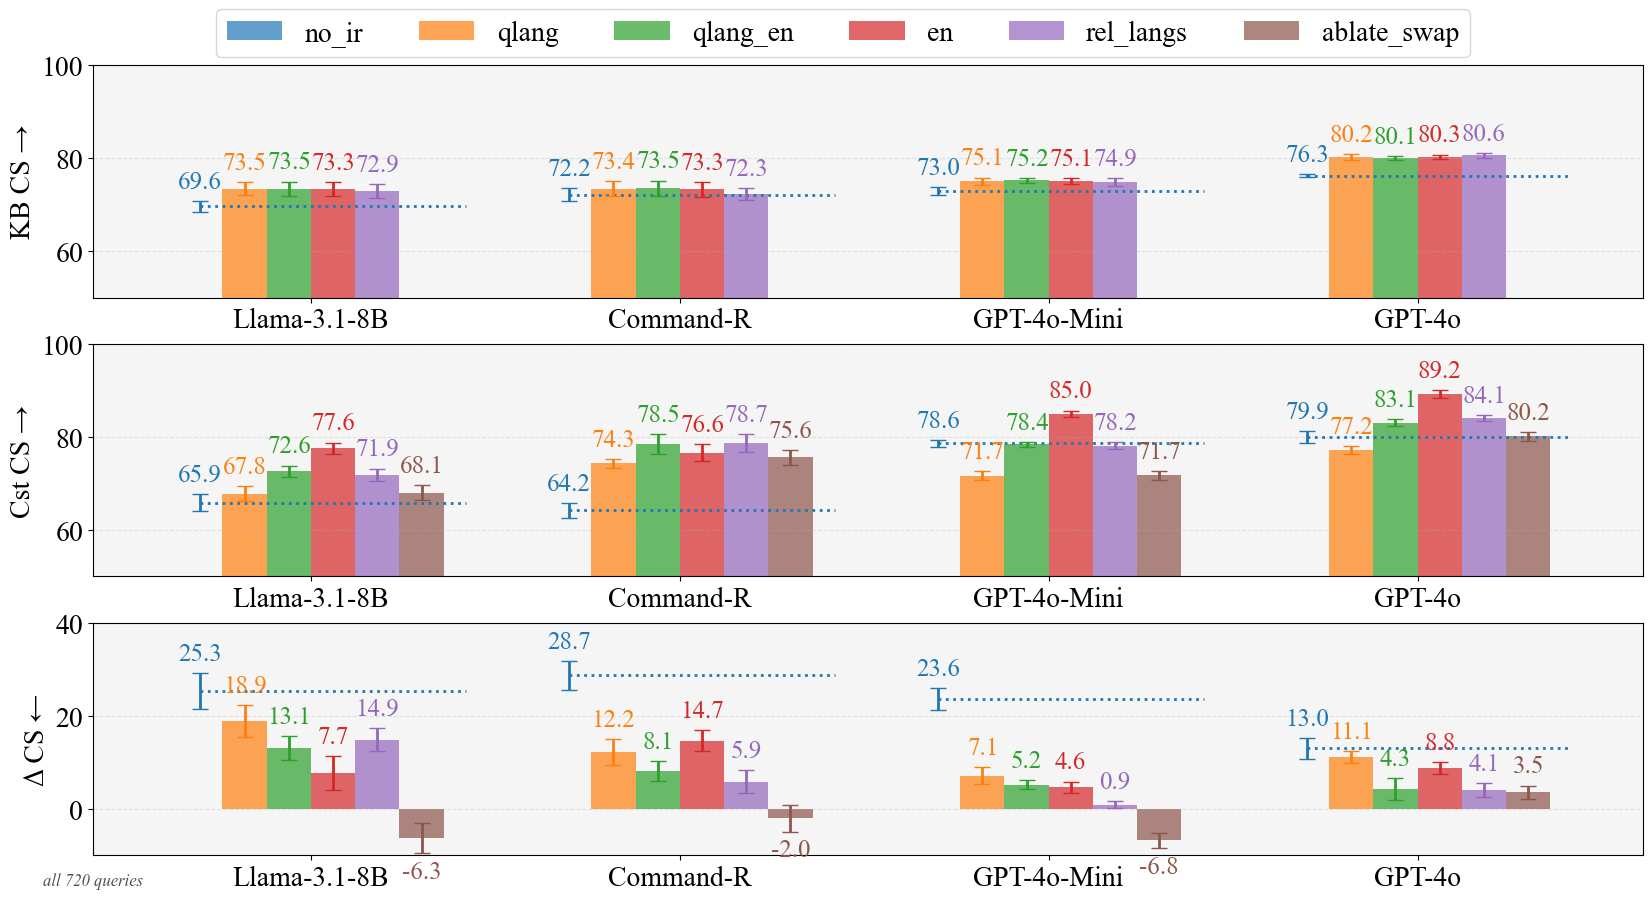

In [102]:
# All Modes Plot

df = pd.read_csv("../generation/gen_results/multirun/metrics/scores_for_all.csv")
models = MODELS
model_labels = MODEL_LABELS
ir_modes = ['no_ir', 'qlang', 'qlang_en', 'en', 'rel_langs', 'ablate_swap']
bar_colors = BAR_COLORS
y_labels = Y_LABELS
ci_map = CI_MAP

plot_modes(df, models, model_labels, ir_modes, bar_colors, y_labels, ci_map=ci_map, figsize=(20,10), bar_width=0.12)

## Select modes

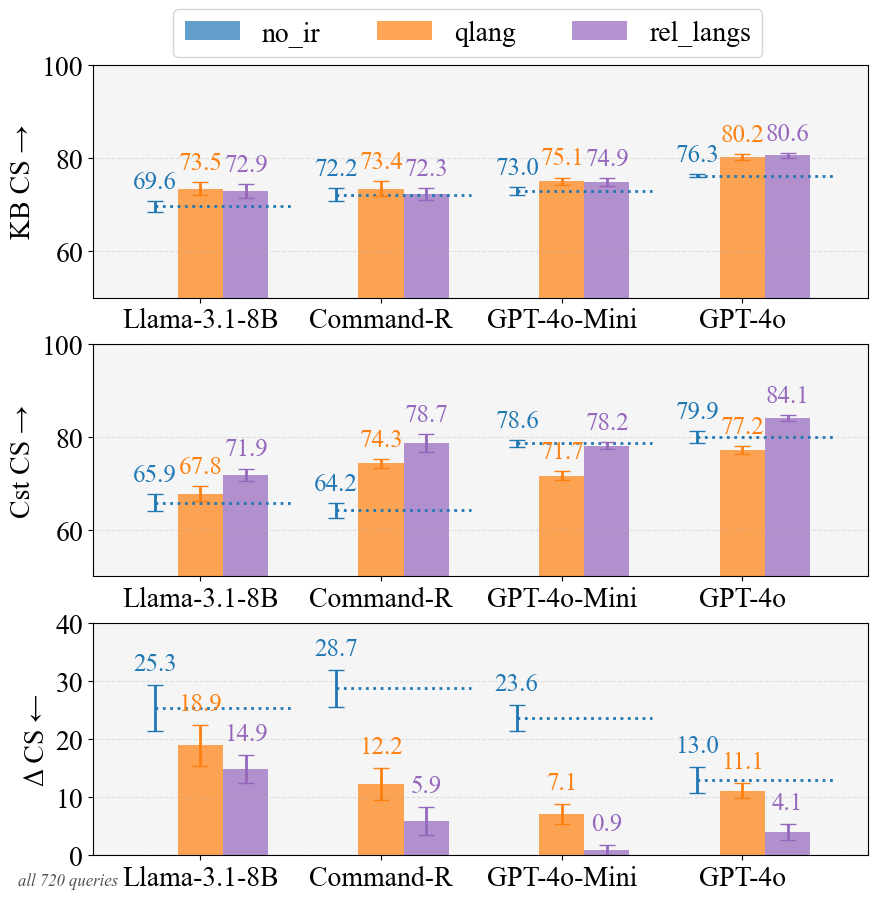

In [110]:
# # Select Modes Plot

ir_modes = ['no_ir', 'qlang', 'rel_langs']
bar_colors = [BAR_COLORS[0], BAR_COLORS[1], BAR_COLORS[4]]
y_labels = {'KB CS': 'KB CS →', 'Consistency CS all': 'Cst CS →', 'Delta CS': 'Δ CS ←'}

plot_modes(df, models, model_labels, ir_modes, bar_colors, y_labels, ci_map=ci_map, figsize=(10,10), bar_width=0.25)


## Relevance Filter

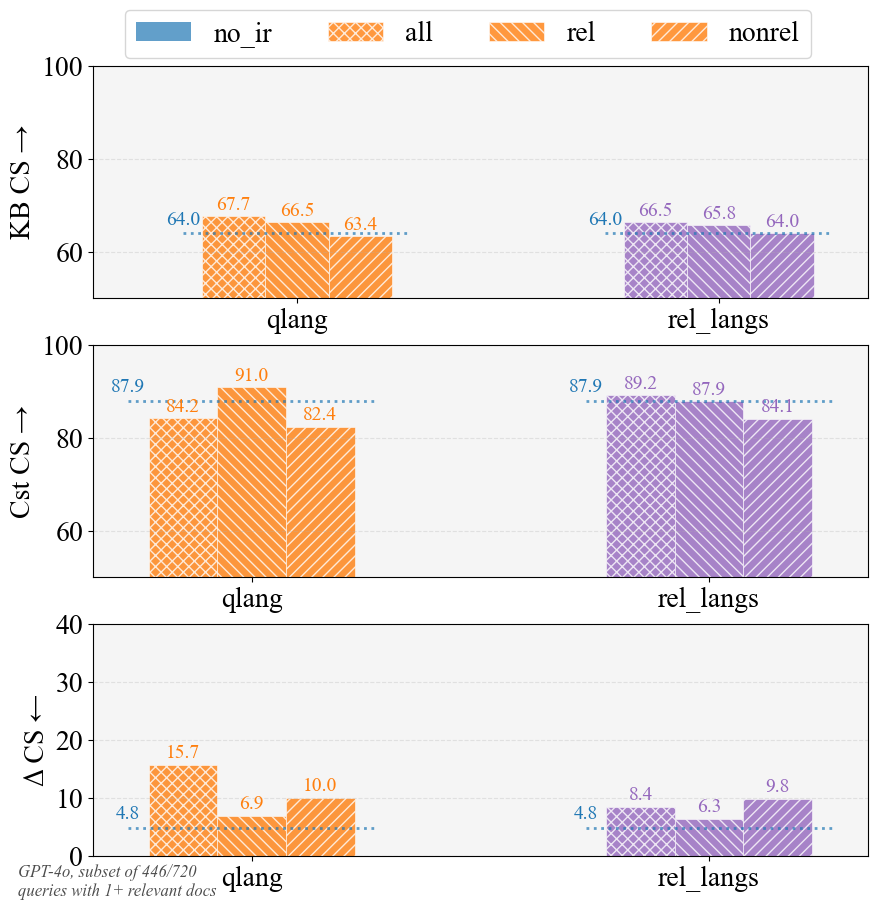

In [108]:
# Relevance Filter Plot

data = pd.read_csv("../generation/gen_results_rel/metrics/scores_for_all.csv")
languages = ['qlang', 'rel_langs']
categories = ['all', 'rel', 'nonrel']
ci_map = CI_MAP

plot_relevance_filter(data, languages, categories, bar_width=0.15, figsize=(10,10), ci_map=ci_map)